<a href="https://colab.research.google.com/github/RanaAAAli/bachelor-/blob/main/notebook71d6f1caa9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [56]:
from google.colab import files
uploaded = files.upload()


Saving EHR.csv to EHR (4).csv


In [57]:
df = pd.read_csv('EHR.csv')

print("Initial Dataset Shape:", df.shape)
df.head()

Initial Dataset Shape: (1447, 29)


,patientunitstayid,patienthealthsystemstayid,gender,age,ethnicity,hospitalid,wardid,apacheadmissiondx,admissionheight,hospitaladmittime24,...,unitadmitsource,unitvisitnumber,unitstaytype,admissionweight,dischargeweight,unitdischargetime24,unitdischargeoffset,unitdischargelocation,unitdischargestatus,uniquepid
0,210014,182373,Male,45,Caucasian,73,89,"Hypertension, uncontrolled (for cerebrovascula...",178.0,13:08:59,...,Direct Admit,1,admit,116.0,112.7,15:00:00,4424,Skilled Nursing Facility,Alive,002-10665
1,200026,174624,Male,50,Caucasian,71,87,Ablation or mapping of cardiac conduction pathway,177.8,10:41:00,...,Operating Room,1,admit,106.1,106.1,17:40:00,1548,Home,Alive,002-10715
2,221131,190993,Male,83,Caucasian,71,87,"Endarterectomy, carotid",175.3,21:43:00,...,Operating Room,1,admit,NaN,72.1,17:46:00,1203,Home,Alive,002-10249
3,221215,191054,Male,49,Caucasian,71,87,"Infarction, acute myocardial (MI)",185.4,03:16:00,...,Emergency Department,1,admit,145.3,146.6,19:07:00,1562,Home,Alive,002-10627
4,217835,188445,Male,57,Caucasian,73,92,"CABG alone, coronary artery bypass grafting",172.7,01:09:00,...,Operating Room,1,admit,NaN,80.4,08:25:00,4719,Floor,Alive,002-10324


In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1447 entries, 0 to 1446
Data columns (total 29 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   patientunitstayid          1447 non-null   int64  
 1   patienthealthsystemstayid  1447 non-null   int64  
 2   gender                     1444 non-null   object 
 3   age                        1446 non-null   object 
 4   ethnicity                  1405 non-null   object 
 5   hospitalid                 1447 non-null   int64  
 6   wardid                     1447 non-null   int64  
 7   apacheadmissiondx          1267 non-null   object 
 8   admissionheight            1402 non-null   float64
 9   hospitaladmittime24        1447 non-null   object 
 10  hospitaladmitoffset        1447 non-null   int64  
 11  hospitaladmitsource        1218 non-null   object 
 12  hospitaldischargeyear      1447 non-null   int64  
 13  hospitaldischargetime24    1447 non-null   objec

In [59]:
print("Missing Values:\n", df.isnull().sum())
print("\nSummary Statistics:\n", df.describe())

Missing Values:
 patientunitstayid              0
patienthealthsystemstayid      0
gender                         3
age                            1
ethnicity                     42
hospitalid                     0
wardid                         0
apacheadmissiondx            180
admissionheight               45
hospitaladmittime24            0
hospitaladmitoffset            0
hospitaladmitsource          229
hospitaldischargeyear          0
hospitaldischargetime24        0
hospitaldischargeoffset        0
hospitaldischargelocation      8
hospitaldischargestatus        7
unittype                       0
unitadmittime24                0
unitadmitsource               19
unitvisitnumber                0
unitstaytype                   0
admissionweight              134
dischargeweight              576
unitdischargetime24            0
unitdischargeoffset            0
unitdischargelocation          5
unitdischargestatus            2
uniquepid                      0
dtype: int64

Summary Stat

In [60]:
# Split dataset WITHOUT overlap
df_A = df.sample(frac=0.33, random_state=1)

remaining = df.drop(df_A.index)
df_B = remaining.sample(frac=0.5, random_state=2)

df_C = remaining.drop(df_B.index)

# Add hospital labels
df_A = df_A.copy()
df_B = df_B.copy()
df_C = df_C.copy()

df_A['Hospital'] = 'Hospital_A'
df_B['Hospital'] = 'Hospital_B'
df_C['Hospital'] = 'Hospital_C'

In [61]:
# Always work on copies to avoid warnings
df_B.loc[:, 'gender'] = df_B['gender'].replace({'Male': 'M', 'Female': 'F'})
df_C.loc[:, 'gender'] = df_C['gender'].astype(str).str.lower()

# Add missing values safely
sample_idx = df_A.sample(frac=0.1, random_state=1).index
df_A.loc[sample_idx, 'age'] = np.nan

# Diagnosis inconsistency (if column exists)
if 'apacheadmissiondx' in df_C.columns:
    df_C.loc[:, 'apacheadmissiondx'] = df_C['apacheadmissiondx'].astype(str).str.upper()

In [62]:
df_fragmented = pd.concat([df_A, df_B, df_C], ignore_index=True)

print("Fragmented Dataset Shape:", df_fragmented.shape)

Fragmented Dataset Shape: (1447, 30)


In [63]:
import pandas as pd

# Standardize gender
df_fragmented['gender'] = (
    df_fragmented['gender']
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        'm': 'Male',
        'male': 'Male',
        'f': 'Female',
        'female': 'Female'
    })
)
# Fix age column using pd.to_numeric to handle non-numeric strings
df_fragmented['age'] = pd.to_numeric(df_fragmented['age'], errors='coerce')

# Remove invalid values
df_fragmented.loc[
    (df_fragmented['age'] < 0) | (df_fragmented['age'] > 120),
    'age'
] = np.nan

# Fill missing values with median
df_fragmented['age'] = df_fragmented['age'].fillna(df_fragmented['age'].median())


if 'apacheadmissiondx' in df_fragmented.columns:
    df_fragmented['apacheadmissiondx'] = (
        df_fragmented['apacheadmissiondx']
        .astype('string')
        .str.strip()
        .str.lower()
    )

    # Fix accidental string 'nan'
    df_fragmented['apacheadmissiondx'] = df_fragmented['apacheadmissiondx'].replace('nan', np.nan)

In [64]:
# Explicitly use .copy() to avoid SettingWithCopyWarning later
if 'patienthealthsystemstayid' in df_fragmented.columns:
    df_cleaned = df_fragmented.drop_duplicates(subset=['patienthealthsystemstayid']).copy()
else:
    df_cleaned = df_fragmented.copy()

print("Cleaned Dataset Shape:", df_cleaned.shape)

Cleaned Dataset Shape: (1242, 30)


In [65]:
# Calculate length of stay if not already present
if 'length_of_stay_days' not in df_cleaned.columns:
    df_cleaned['length_of_stay_hours'] = df_cleaned['unitdischargeoffset'] / 60
    df_cleaned['length_of_stay_days'] = df_cleaned['length_of_stay_hours'] / 24

# Top diagnoses
print("Top 10 Diagnoses:")
print(df_cleaned['apacheadmissiondx'].value_counts().head(10))

# Hospital distribution
print("\nHospital Distribution:")
print(df_cleaned['Hospital'].value_counts())

# Average length of stay per diagnosis
print("\nAverage Length of Stay per Diagnosis (Top 10):")
print(df_cleaned.groupby('apacheadmissiondx')['length_of_stay_days'].mean().sort_values(ascending=False).head(10))

# Mortality rate
print("\nMortality Rate (%):")
print(df_cleaned['hospitaldischargestatus'].value_counts(normalize=True) * 100)

Top 10 Diagnoses:
apacheadmissiondx
sepsis, pulmonary                                                                                     73
chf, congestive heart failure                                                                         49
rhythm disturbance (atrial, supraventricular)                                                         46
infarction, acute myocardial (mi)                                                                     44
sepsis, renal/uti (including bladder)                                                                 33
angina, unstable (angina interferes w/quality of life or meds are tolerated poorly)                   33
bleeding, gi-location unknown                                                                         30
diabetic ketoacidosis                                                                                 29
cva, cerebrovascular accident/stroke                                                                  29
cardiac arrest (wit

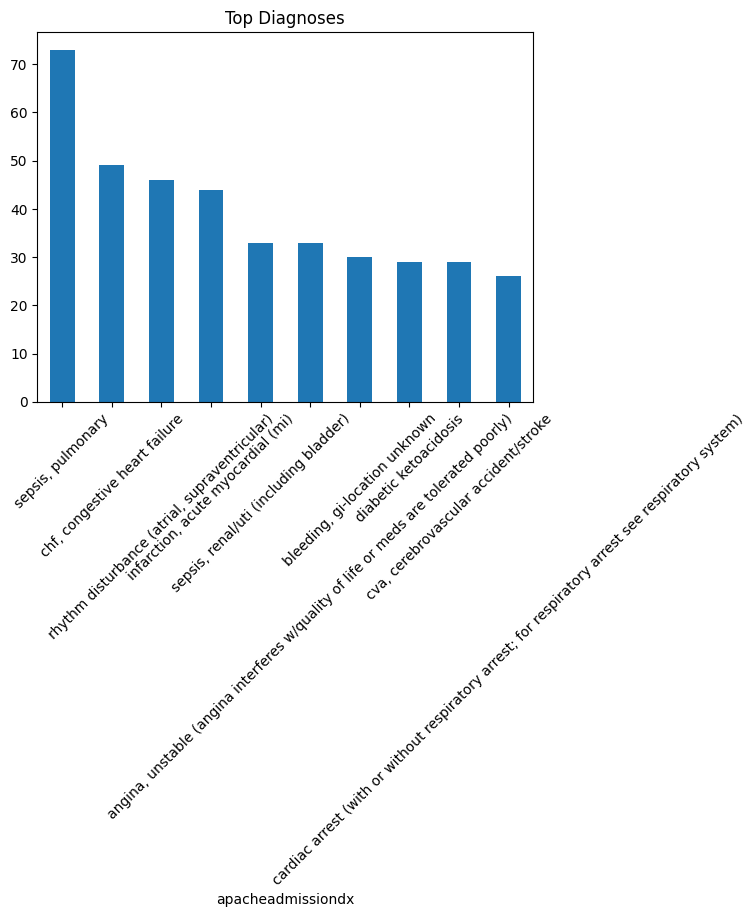

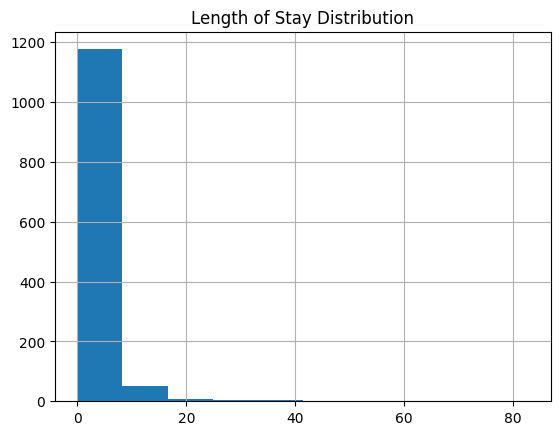

In [66]:
import matplotlib.pyplot as plt

# Top diagnoses
df_cleaned['apacheadmissiondx'].value_counts().head(10).plot(kind='bar')
plt.title("Top Diagnoses")
plt.xticks(rotation=45)
plt.show()

# Length of stay distribution
df_cleaned['length_of_stay_days'].hist()
plt.title("Length of Stay Distribution")
plt.show()

In [67]:
# Define high_risk_flag if it doesn't exist (e.g., age > 65)
if 'high_risk_flag' not in df_cleaned.columns:
    df_cleaned['high_risk_flag'] = (df_cleaned['age'] > 65).astype(int)

total_patients = df_cleaned['patienthealthsystemstayid'].nunique()
avg_los = df_cleaned['length_of_stay_days'].mean()
high_risk_count = df_cleaned['high_risk_flag'].sum()
mortality_rate = (df_cleaned['hospitaldischargestatus'] == 'Expired').mean() * 100

print(f"Total Patients: {total_patients}")
print(f"Average LOS (Days): {avg_los:.2f}")
print(f"High Risk Count: {high_risk_count}")
print(f"Mortality Rate: {mortality_rate:.2f}%")

Total Patients: 1242
Average LOS (Days): 2.74
High Risk Count: 662
Mortality Rate: 8.37%


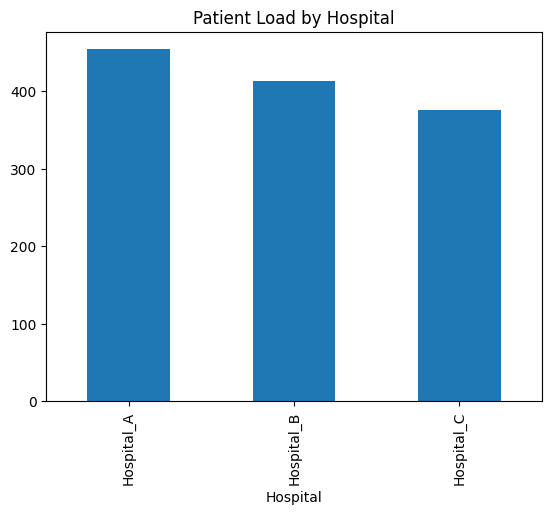

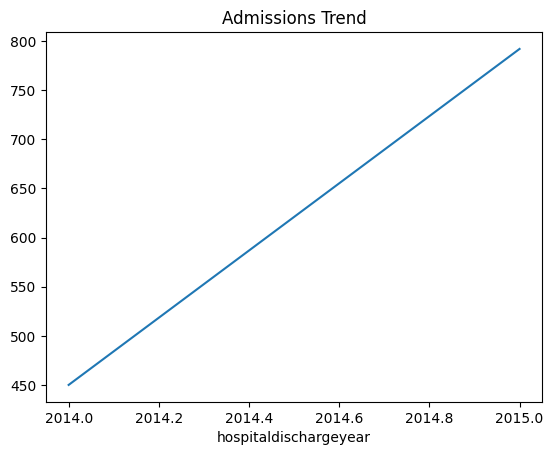

In [68]:
# Patients per hospital
df_cleaned['Hospital'].value_counts().plot(kind='bar')
plt.title("Patient Load by Hospital")
plt.show()

# Admission trends (simulate time-based insight)
df_cleaned.groupby('hospitaldischargeyear').size().plot()
plt.title("Admissions Trend")
plt.show()

In [70]:
# Correct length of stay calculation
df_cleaned['length_of_stay_hours'] = df_cleaned['unitdischargeoffset'] / 60
df_cleaned['length_of_stay_days'] = df_cleaned['length_of_stay_hours'] / 24

In [71]:
if all(col in df_cleaned.columns for col in ['hospitaladmittime24', 'hospitaldischargetime24']):
    # Convert columns to datetime to allow for subtraction
    df_cleaned['hospitaladmittime24'] = pd.to_datetime(df_cleaned['hospitaladmittime24'], format='%H:%M:%S', errors='coerce')
    df_cleaned['hospitaldischargetime24'] = pd.to_datetime(df_cleaned['hospitaldischargetime24'], format='%H:%M:%S', errors='coerce')

    # Calculate length of stay
    df_cleaned['length_of_stay'] = (
        df_cleaned['hospitaldischargetime24'] - df_cleaned['hospitaladmittime24']
    )

In [72]:
# KPI Metrics
total_patients = df_cleaned['patienthealthsystemstayid'].nunique()
avg_los = df_cleaned['length_of_stay_days'].mean()
high_risk_patients = df_cleaned['high_risk_flag'].sum()
mortality_rate = (df_cleaned['hospitaldischargestatus'] == 'Expired').mean() * 100

print("Total Patients:", total_patients)
print("Avg Length of Stay:", round(avg_los, 2))
print("High Risk Patients:", high_risk_patients)
print("Mortality Rate (%):", round(mortality_rate, 2))

Total Patients: 1242
Avg Length of Stay: 2.74
High Risk Patients: 662
Mortality Rate (%): 8.37


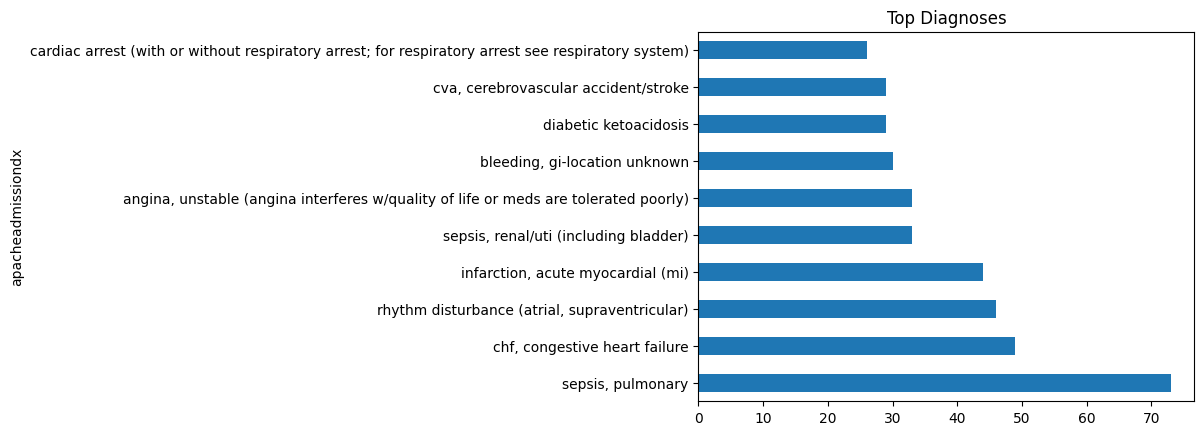

In [74]:
# Top diagnoses
df_cleaned['apacheadmissiondx'].value_counts().head(10).plot(kind='barh')
plt.title("Top Diagnoses")
plt.show()

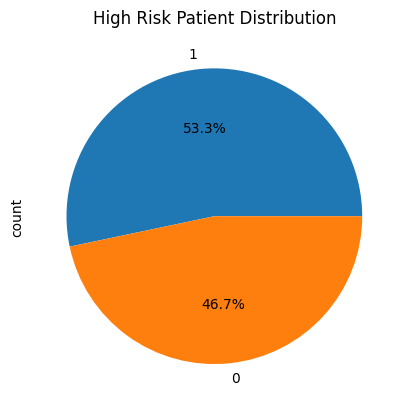

In [75]:
# Risk distribution
df_cleaned['high_risk_flag'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("High Risk Patient Distribution")
plt.show()

In [77]:
# Example filter
filtered_df = df_cleaned[df_cleaned['Hospital'] == 'Hospital_A']